# Emerging Technologies
**Name**: Macdarach Carty Joyce <br>
**ID**: G00394925

## Introduction


In [1]:
import numpy as np
import random
import itertools
import qiskit
import qiskit_aer as aer
import matplotlib.pyplot as plt
import pylatexenc

## Problem 1: Generating Random Boolean Functions
<hr>
<br>
This problem relates to the implementation of a function that returns a boolean output based on a fixed number of boolean inputs. The function may either be <b>constant</b> (always return <code>True</code> or <code>False</code>) or <b>balanced</b> (half of possible combinations return <code>True</code>). This is achieved by generating and returning a function from <i>within</i> another function, the former of which then outputs a boolean output. The goal is to implement this so that the nature of the function (be it constant or balanced) remains unknown to the observer.  

In this case, for $x=\{0,1\}$, a randomly chosen function will either be: 
- **Constant**: Always return 0 ($f_0$) or always return 1 ($f_3$) regardless of input combination.
- **Balanced**: Return 0 for half of the input combinations and 1 for the other half ($f_1, f_2$).   

| $x$ | $f_0(x)$ | $f_1(x)$ | $f_2(x)$ | $f_3(x)$ |
|-----|---------|---------|---------|---------|
|  0  |    0    |    0    |    1    |    1    |
|  1  |    0    |    1    |    0    |    1    |

The approach used here begins with the generation of all possible binary strings of length $n$. If $n = 4$, this would mean generating $2^4$ possible combinations of binary strings: $[0, 0, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0], [0, 0, 1, 1],...[1, 1, 1, 1]$. Once all possible combinations are acquired, only the constant (all 0's or 1's) or balanced (exactly half 1's) strings are returned.

In [2]:
def constant_and_balanced_strings(n):
    """
    Generates all constant and balanced binary strings of length n.
    
    Parameters:
        n (int): Length of the binary strings.
    Returns:
        np.ndarray: Array of constant and balanced binary strings.
    """
    # Generate all possible binary strings of length n
    all_binary_strings = ((np.arange(2**n)[:, None] & (1 << np.arange(n-1, -1, -1))) > 0).astype(int)

    # Acquire the sum of ones in each binary string
    ones = all_binary_strings.sum(axis=1)

    # Length of a binary string
    str_len = all_binary_strings.shape[1]

    # Return only the constant (all 0s or all 1s) or balanced (equal number of 0s and 1s) strings
    return all_binary_strings[(ones == 0) | (ones == str_len) | (ones == str_len // 2)]

Once the relevant strings have been returned, a random choice is made to either use a constant or balanced string before proceeding to choose a random string of either category. An inner variadic function is generated which maps the boolean inputs to the randomly selected string using standard binary-to-decimal conversion to calculate the index.  

Given $n$ binary inputs, the binary-to-decimal conversion formula would be as follows: <br>
<br>
$b_0 \times 2^0 + b_1 \times 2^1 ... + b_{n-1} \times 2^{n-1}$

So, given a balanced truth table of $[1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0]$, and the boolean inputs $(0, 1, 0, 1)$, by reversing the bit order to start with the least significant bit, we calculate the index as: <br>
<br>
$1 \times 2^0 + 0 \times 2^1 + 1 \times 2^2 + 0 \times 2^3 = 1 + 0 + 4 + 0 = 5$. 

Element $[5]$ is then acquired from the above truth table, which is $0$. Therefore, the specific input combination of $(0, 1, 0, 1)$ returns an output of 0.

In [3]:
def random_constant_balanced(n):
    """
    Creates and returns a function that randomly selects a binary string.

    Parameters:
        n (int): Number of input bits for the function.
    Returns:
        function: A function that maps n inputs to a randomly selected constant or balanced binary string.
    """
    
    # Acquire all constant and balanced strings of length 2^n
    strings = constant_and_balanced_strings(2 ** n)

    constant_strings = [s for s in strings if s.sum() == 0 or s.sum() == len(s)]
    balanced_strings = [s for s in strings if s.sum() == len(s) // 2]

    # Decide whether to select a constant or balanced string.
    string_type = random.choice(['constant', 'balanced'])

    # Randomly select one of these strings
    if string_type == 'constant':
        random_string = random.choice(constant_strings)
    else:
        random_string = random.choice(balanced_strings)

    
    def f(*args):
        """
        Maps n inputs to the corresponding bit in the randomly selected binary string.

        Parameters:
            *args: n binary inputs (0 or 1).
        Returns:
            int: The bit in the random string corresponding to the binary index formed by the inputs.
        """

        index = 0

        # Get index from binary inputs
        for i, bit in enumerate(reversed(args)):
            # Calculate the index in decimal (bit*2^0 + bit*2^1 + ... + bit*2^(n-1))
            index += (bit * (2 ** i))
            
        return int(random_string[index])
    
    # Store n as an attribute for later use
    f.n = n
    
    return f

### Test the function

In [4]:
# Acquire the function 
f = random_constant_balanced(4)

In [5]:
# Test the function with binary inputs
print(f(1, 1, 1, 1))

1


## Problem 2: Classical Testing for Function Type
<hr>

This section involves determining whether the function previously generated in Problem 1 is constant or balanced. This is a **Classical** approach; that is, the state of the function is clearly observed and known with certainty. If this determination were to be labelled as X, and there is a 50% chance of the function being either constant or balanced, we can represent the probabilities of such as:

$$Pr(X = constant) = \frac{1}{2} \quad \text{and} \quad Pr(X = balanced) = \frac{1}{2}$$

which can also be represented as a **column vector**: 

$$\begin{pmatrix} \frac{1}{2} \\ \\ \frac{1}{2} \end{pmatrix}$$

where the probability of the function being *constant* is placed at the top position, and the probability of the function being *balanced* is placed at the bottom, as well as the sum of these entries being always equal to 1.

The functions of Deutsch's algorithm can be represented as a 2x2 matrix, showing the output for each input:

$$
f_0(x) = \begin{pmatrix} 1 \quad 1 \\ 0 \quad 0 \end{pmatrix} \quad
f_1(x) = \begin{pmatrix} 1 \quad 0 \\ 0 \quad 1 \end{pmatrix} \quad
f_2(x) = \begin{pmatrix} 0 \quad 1 \\ 1 \quad 0 \end{pmatrix} \quad
f_3(x) = \begin{pmatrix} 0 \quad 0 \\ 1 \quad 1 \end{pmatrix} \quad
$$

When the the outcome of *determine_constant_balanced(f)* is observed, the classical state of the given function is known with certainty. This can be represented as a standard basis vector, and is represented as:

$$
|constant\rangle = \begin{pmatrix} 
    1 \\ 0 
\end{pmatrix}

\quad \text{and} \quad

|balanced\rangle = \begin{pmatrix}
    0 \\ 1
\end{pmatrix}
$$
https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/single-systems/classical-information

 In this approach, the output is determined by iterating through all possible input combinations against the truth table and analysing the result of <code>f</code>. The logic is as follows:

1. Get the output for the first input combination.
2. Iterate through the remaining operations.
3. If any output differs from the previous output, the function must be **balanced**.
4. If all outputs are the same and the loop completes, the function must be **constant**.

This can be determined after a minimum of 2 iterations (where the function is balanced), or after a maximum of $n$ iterations, where $n$ is equivalent to the number of input bits. 

In [6]:
def determine_constant_balanced(f):
    """
    Determines whether the given function is constant (returns 0 or 1 for all inputs) or 
    balanced (returns 0 for half of the inputs, 1 for the other half).

    Parameters: 
        f (function): The generated function being tested.

    Returns:
        A string saying whether the function is constant or balanced.
    """
    
    n = f.n  # Get number of inputs from the function attribute
    previous_output = None

    # Generate all possible input combinations dynamically
    all_inputs = itertools.product([0, 1], repeat=n)
    
    # Run f for all possible input combinations
    for i, inputs in enumerate(all_inputs):        
        out = f(*inputs)
        
        if previous_output is not None:
            # Output is different across different input combinations -- must be balanced.
            if out != previous_output:
                return "Balanced"
        
        previous_output = out
    
    return "Constant"  # If all outputs are the same

### Execute the function

In [7]:
determine_constant_balanced(f)

'Balanced'

## Problem 3: Quantum Oracles
<hr>


In Quantum Information, the state of a given input is measured more arbitrarily than that of classical states. In a classical state set of $\{0, 1\}$, the term *qubit* is used to refer to a unit of quantum information. 

The processing of quantum information differs to classical information; a process that evaluates a function $f$ using an input of 0 or 1 to determine whether it is **constant** or **balanced** would have to be run at least twice under classical methods (as demonstrated in **Problem 2**), whereas the sue of quantum information and operations allows for the determination of $f$ in one evaluation.


Quantum Oracles act as the 'black-box' operations that evaluate $f$. These implement the transformation:
$$x\rangle|y\rangle \rightarrow |x\rangle|y \oplus f(x)\rangle$$

Where $\oplus$ is the **tensor** product, and $f$ could one of the four functions in Deutsch's Algorithm: 


| $x$ | $f_1(x)$ | $f_2(x)$ | $f_3(x)$ | $f_4(x)$ |
|-----|---------|---------|---------|---------|
|  0  |    0    |    0    |    1    |    1    |
|  1  |    0    |    1    |    0    |    1    |


So, the tensor product of the following 2 column vectors 
$$\begin{pmatrix} 1 \\ 0 \end{pmatrix} \oplus \begin{pmatrix} 1 \\ 0 \end{pmatrix}$$

becomes:

$$\begin{pmatrix} 1 \\ 0 \\ 0 \\ 0 \end{pmatrix}$$

which is how multi-qubit states are represented, with this particular example showing the state $|00\rangle$ (constant 0 function). 

We can calculate the column vectors for the other functions too:

$$
\begin{pmatrix} 1 \\ 0 \end{pmatrix} \oplus \begin{pmatrix} 0 \\ 1 \end{pmatrix} = 
\begin{pmatrix} 0 \\ 1 \\ 0 \\ 0 \end{pmatrix}
$$

With the operation being unknown to the observer, the only properties that are known are the inputs supplied and the given outputs. With regards to the previous problems; in the case of a single input, there are four possible Boolean functions. This section sees the creation of a quantum oracle using *Qiskit* for each of the possible single-Boolean-input functions.


https://plato.stanford.edu/archives/fall2008/entries/qt-entangle/#5

https://quantumcomputing.stackexchange.com/questions/4625/what-exactly-is-an-oracle/4626#4626

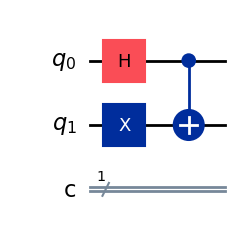

In [8]:
qc = qiskit.QuantumCircuit(2, 1)

qc.x(1)
qc.h(0)
qc.cx(0, 1)
qc.draw(output='mpl')

## Problem 4: Deutsch's Algorithm with Qiskit

## Problem 5: Scaling to the Deutsch-Jozsa Algorithm